In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, StratifiedKFold
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
import math
from xgboost import XGBRegressor

In [2]:
# Reading HSP and SMILES data 
gpHSP_data = pd.read_csv('/Users/favour/Desktop/untitled folder/dataset/hansen_1k_smiles_shorter.csv')

mol_smiles = gpHSP_data['SMILES']
hansen_d = gpHSP_data['hansen_d']
hansen_p = gpHSP_data['hansen_p']
hansen_h = gpHSP_data['hansen_h']
mol_number = gpHSP_data['number']
mol_name = gpHSP_data['Molecule']

# calculate total sobubility from HSP
hansen_total = np.sqrt((hansen_d*hansen_d + hansen_p*hansen_p + hansen_h*hansen_h))

In [3]:
# generate fingeprints: Morgan fingerprint with radius 8 with nBits 2048
fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(x), 8, nBits=2048) for x in gpHSP_data['SMILES']]
#convert fps into numpy array
np_fps = np.asarray(fps)
np_fps.shape

# generate MACCS fingerprints
#maccs_fps = [MACCSkeys.GenMACCSKeys (Chem.MolFromSmiles(x)) for x in gpHSP_data['smiles']]

[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerator
[14:23:08] DEPRECATION WARNING: please use MorganGenerat

(1183, 2048)

Fold:1, Train set: 985, Test set:198
MAE  : 2.3746
RMSE : 3.2979
R2   : 0.4860


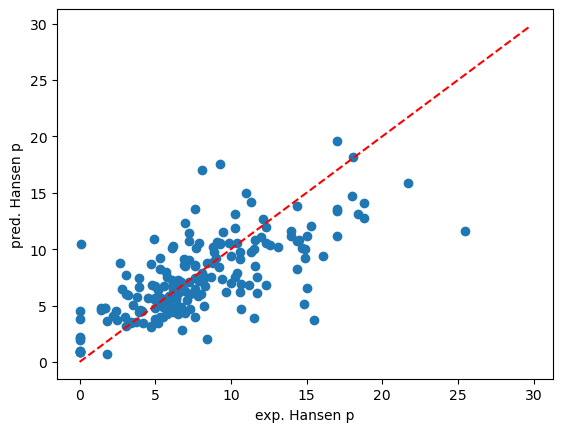

Fold:2, Train set: 986, Test set:197
MAE  : 2.4180
RMSE : 3.2876
R2   : 0.4137


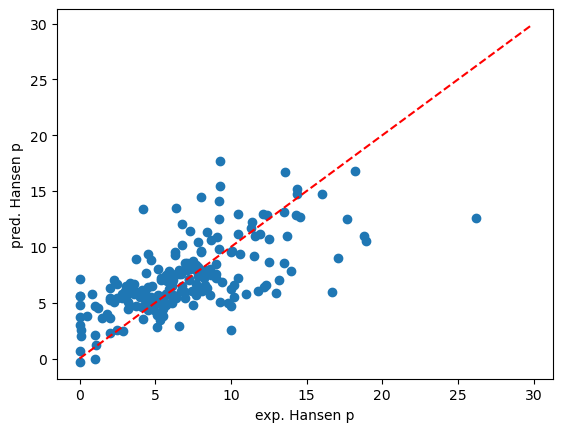

Fold:3, Train set: 986, Test set:197
MAE  : 2.2102
RMSE : 2.9011
R2   : 0.4709


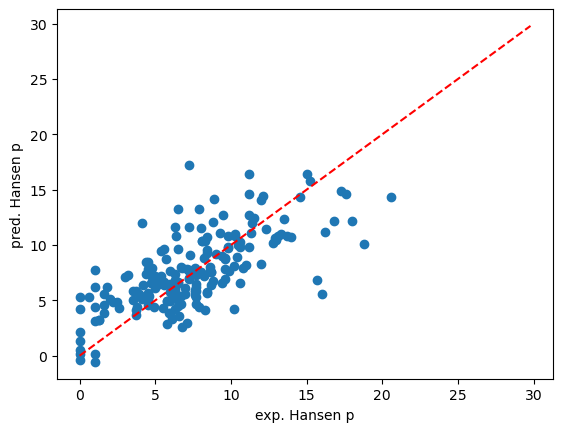

Fold:4, Train set: 986, Test set:197
MAE  : 2.1433
RMSE : 2.9713
R2   : 0.4988


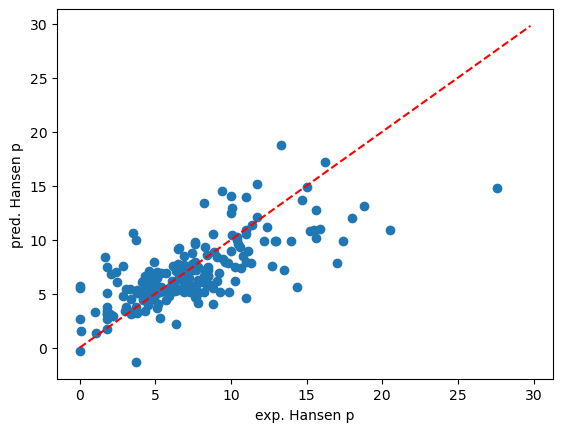

Fold:5, Train set: 986, Test set:197
MAE  : 2.2173
RMSE : 3.0422
R2   : 0.5409


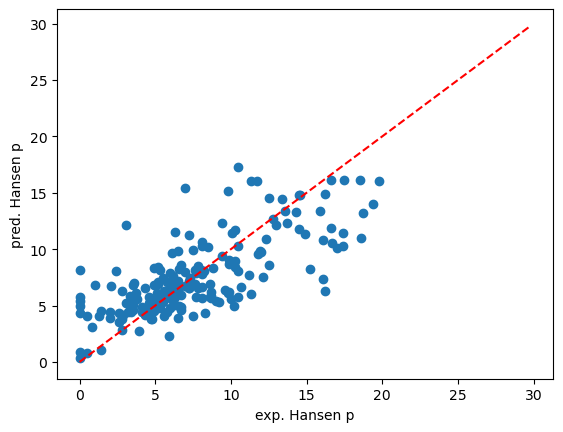

Fold:6, Train set: 986, Test set:197
MAE  : 2.0452
RMSE : 2.7815
R2   : 0.5785


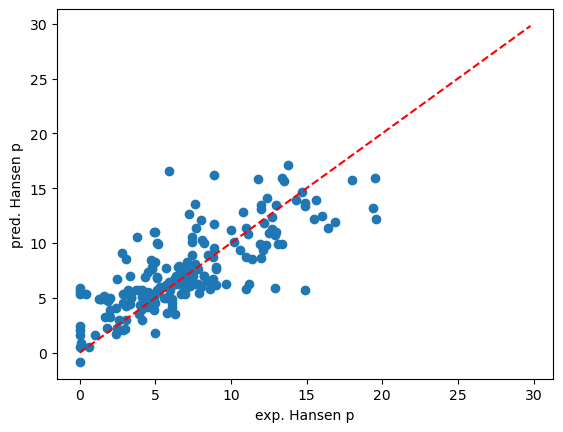


=== 6-Fold CV Summary (Hansen p) ===
MAE  : 2.2348 ± 0.1402
RMSE : 3.0469 ± 0.2090
R2   : 0.4982 ± 0.0571


In [4]:
import numpy as np
import pandas as pd
import math
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

kf = KFold(n_splits=6, shuffle=True, random_state=42)

# store metrics
mae_scores = []
rmse_scores = []
r2_scores = []

cnt = 1

for train_index, test_index in kf.split(np_fps, hansen_p):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')

    fps_train, fps_test = np_fps[train_index], np_fps[test_index]
    hansen_train, hansen_test = hansen_p[train_index], hansen_p[test_index]
    index_test = mol_number[test_index]
    smiles_test = mol_smiles[test_index]

    # train + predict
    model = XGBRegressor()
    model.fit(fps_train, hansen_train)
    hansen_pred = model.predict(fps_test)

    # metrics
    fold_mae = mean_absolute_error(hansen_test, hansen_pred)
    fold_rmse = math.sqrt(mean_squared_error(hansen_test, hansen_pred))
    fold_r2 = r2_score(hansen_test, hansen_pred)

    # store
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    r2_scores.append(fold_r2)

    # print fold metrics
    print(f"MAE  : {fold_mae:.4f}")
    print(f"RMSE : {fold_rmse:.4f}")
    print(f"R2   : {fold_r2:.4f}")

    # save fold predictions
    out_df = pd.DataFrame({
        "Mol_No": index_test,
        "SMILES": smiles_test,
        "actual": hansen_test,
        "predict": hansen_pred
    })
    out_df.to_csv(f'fps_xgboost_hansen_p_fold_{cnt}.csv', index=False)

    # plot exp vs pred
    ln = np.arange(0, 30, 0.2)
    plt.plot(ln, ln, 'r--')
    plt.scatter(hansen_test, hansen_pred)
    plt.xlabel('exp. Hansen p')
    plt.ylabel('pred. Hansen p')
    plt.show()

    cnt += 1

# summary mean ± std
mae_scores = np.array(mae_scores)
rmse_scores = np.array(rmse_scores)
r2_scores = np.array(r2_scores)

print("\n=== 6-Fold CV Summary (Hansen p) ===")
print(f"MAE  : {mae_scores.mean():.4f} ± {mae_scores.std(ddof=1):.4f}")
print(f"RMSE : {rmse_scores.mean():.4f} ± {rmse_scores.std(ddof=1):.4f}")
print(f"R2   : {r2_scores.mean():.4f} ± {r2_scores.std(ddof=1):.4f}")

In [5]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import IPythonConsole
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import math

In [6]:
# load predicted values from the previous 6-fold cross-validation as df
fps_xgboost_p_1 = pd.read_csv('fps_xgboost_hansen_p_fold_1.csv')
fps_xgboost_p_2 = pd.read_csv('fps_xgboost_hansen_p_fold_2.csv')
fps_xgboost_p_3 = pd.read_csv('fps_xgboost_hansen_p_fold_3.csv')
fps_xgboost_p_4 = pd.read_csv('fps_xgboost_hansen_p_fold_4.csv')
fps_xgboost_p_5 = pd.read_csv('fps_xgboost_hansen_p_fold_5.csv')
fps_xgboost_p_6 = pd.read_csv('fps_xgboost_hansen_p_fold_6.csv')
# concat the data, rename columns (actual=experimentally determined value)
fps_xgboost = pd.concat((fps_xgboost_p_1, fps_xgboost_p_2, fps_xgboost_p_3, fps_xgboost_p_4, fps_xgboost_p_5, fps_xgboost_p_6),axis=0)
fps_xgboost = fps_xgboost.rename({'3': 'SMILES', '4':'Mol_No', '5': 'actual', '6':'predict'}, axis='columns')

In [7]:
# MAE, AE and RMSE give an idea of the error distribution
print(mean_absolute_error(fps_xgboost['actual'], fps_xgboost['predict']))

#RMSEs
print(math.sqrt(mean_squared_error(fps_xgboost['actual'], fps_xgboost['predict'])))

# R^2 Coefficient of Determination
print(r2_score(fps_xgboost['actual'], fps_xgboost['predict']))

2.2348741627852915
3.0531092967554545
0.5012500289339248


In [8]:
len(fps_xgboost)

1183

In [9]:
# calculate the residual value for each molecule
fps_xgboost['residual']= fps_xgboost['predict']-fps_xgboost['actual']

In [10]:
# calculate standardised deviation of the residuals (sdr) of the dataset
# equations used: sdr = sqrt((sum((residual)**2))/(n-2))
sdr = np.sqrt((fps_xgboost['residual']**2).sum()/(len(fps_xgboost)-2))
sdr

np.float64(3.0556933931103485)

In [11]:
# calculate how many sdr each molecule's predicted value is away from the exp value 
fps_xgboost['std_residual'] = fps_xgboost['residual']/sdr
fps_xgboost['std_residual']

0     -0.514600
1     -0.284144
2     -1.796441
3      3.377670
4     -0.048370
         ...   
192   -0.943814
193   -0.350489
194   -1.057249
195   -0.016848
196   -0.669580
Name: std_residual, Length: 1183, dtype: float64

In [12]:
# n is 2 or 3. Points 2 or 3 sdr away from the prediction line are likely to be outliers
n = 3
fps_xgboost_outliers = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
fps_xgboost_outliers

,Mol_No,SMILES,actual,predict,residual,std_residual
3,44,CCc1ccccc1CC,0.1,10.421125,10.321125,3.377670
39,243,ClC(Cl)(Cl)C=C,15.5,3.726994,-11.773006,-3.852810
44,274,Cc1ccon1,14.8,5.107706,-9.692294,-3.171880
123,733,OCC(O)CO.OC(O)=O,25.5,11.639627,-13.860373,-4.535918
64,367,N,16.7,5.974415,-10.725585,-3.510033
127,725,NC=O,26.2,12.612122,-13.587878,-4.446741
167,966,[O-][O+]=O,4.2,13.414657,9.214657,3.015570
172,1077,Cl[S](Cl)(=O)=O,7.2,17.223400,10.023400,3.280237
194,1180,O,16.0,5.611488,-10.388512,-3.399723
81,473,[Ca++].NC#N,27.6,14.766838,-12.833162,-4.199754


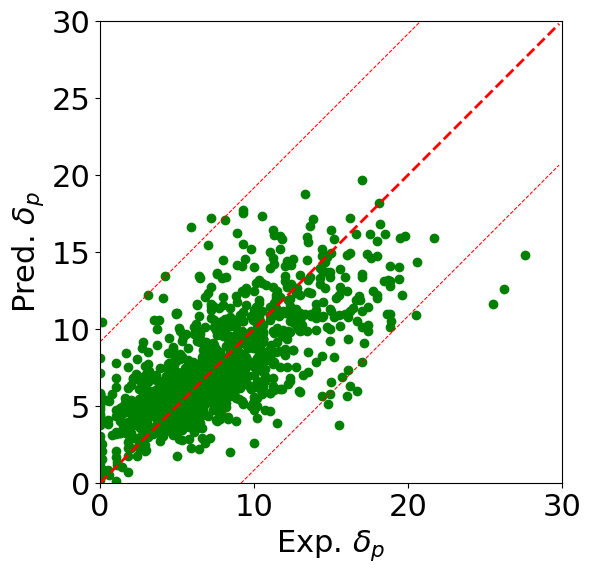

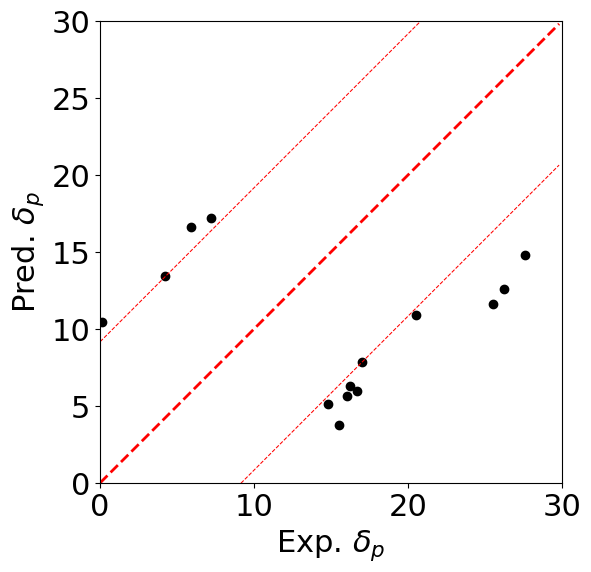

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Set font size
plt.rc('font', size=22)

# residual threshold
n = 3


# -------- Plot 1: all molecules --------
plt.figure(figsize=(6,6))

ln = np.arange(0, 30, 0.2)

# ideal agreement and residual boundaries
plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr, 'r--', linewidth=0.75)

# scatter plot
plt.scatter(x=fps_xgboost['actual'], 
            y=fps_xgboost['predict'], 
            color='green')

plt.xlabel(r'Exp. $\delta_p$')
plt.ylabel(r'Pred. $\delta_p$')

plt.xlim([0,30])
plt.ylim([0,30])

plt.gca().set_aspect('equal', adjustable='box')

# save figure
plt.savefig("xgboost_hansen_p_all_points.png", dpi=300, bbox_inches="tight")

plt.show()



# -------- Plot 2: outliers only --------
plt.figure(figsize=(6,6))

ln = np.arange(0, 30, 0.2)

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost_outliers['actual'], 
            y=fps_xgboost_outliers['predict'], 
            color='black')

plt.xlabel(r'Exp. $\delta_p$')
plt.ylabel(r'Pred. $\delta_p$')

plt.xlim([0,30])
plt.ylim([0,30])

plt.gca().set_aspect('equal', adjustable='box')

# save figure
plt.savefig("xgboost_hansen_p_outliers.png", dpi=300, bbox_inches="tight")

plt.show()

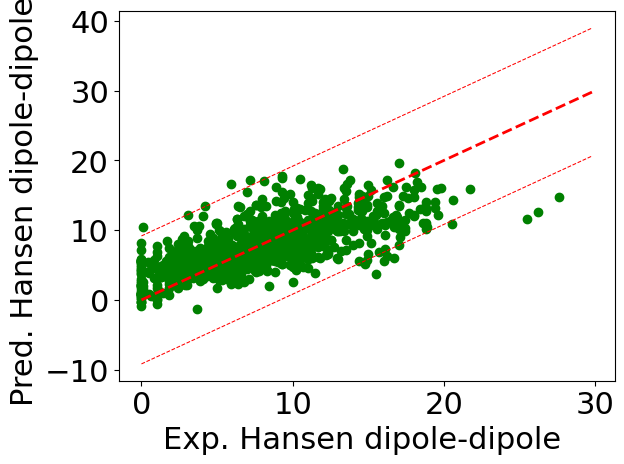

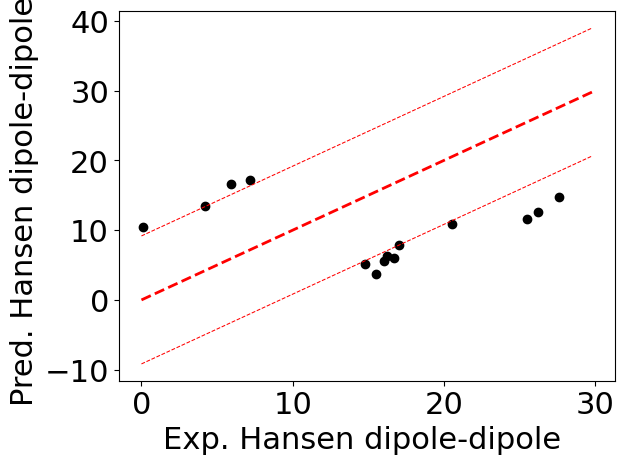

In [14]:
# Set the default text font size
plt.rc('font', size=22)# plot two figures
plt.figure(2)

# plot of exp vs pred of all molecules in the dataset
# The thick red lines indicate ideal agreement between the predicted and experimental values. 
# The dashed red lines indicate 3 srd (n=3) away from the ideal agreement. 
ln = np.arange(0, 30, 0.2)
plt.plot(ln, ln,'r--', linewidth = '2')
plt.plot(ln, ln+n*sdr,'r--', linewidth = '0.75')
plt.plot(ln, ln-n*sdr,'r--', linewidth = '0.75')
plt.scatter(x=fps_xgboost['actual'], y=fps_xgboost['predict'], color='green')
plt.xlabel('Exp. Hansen dipole-dipole ')
plt.ylabel('Pred. Hansen dipole-dipole ')
plt.show()

# Plot of the outliers identified 
# check visually to confirm they are on or beyond 3 srd
ln = np.arange(0, 30, 0.2)
plt.plot(ln, ln,'r--', linewidth = '2')
plt.plot(ln, ln+n*sdr,'r--', linewidth = '0.75')
plt.plot(ln, ln-n*sdr,'r--', linewidth = '0.75')
plt.scatter(x=fps_xgboost_outliers['actual'], y=fps_xgboost_outliers['predict'], color='black')
plt.xlabel('Exp. Hansen dipole-dipole ')
plt.ylabel('Pred. Hansen dipole-dipole ')
plt.show()

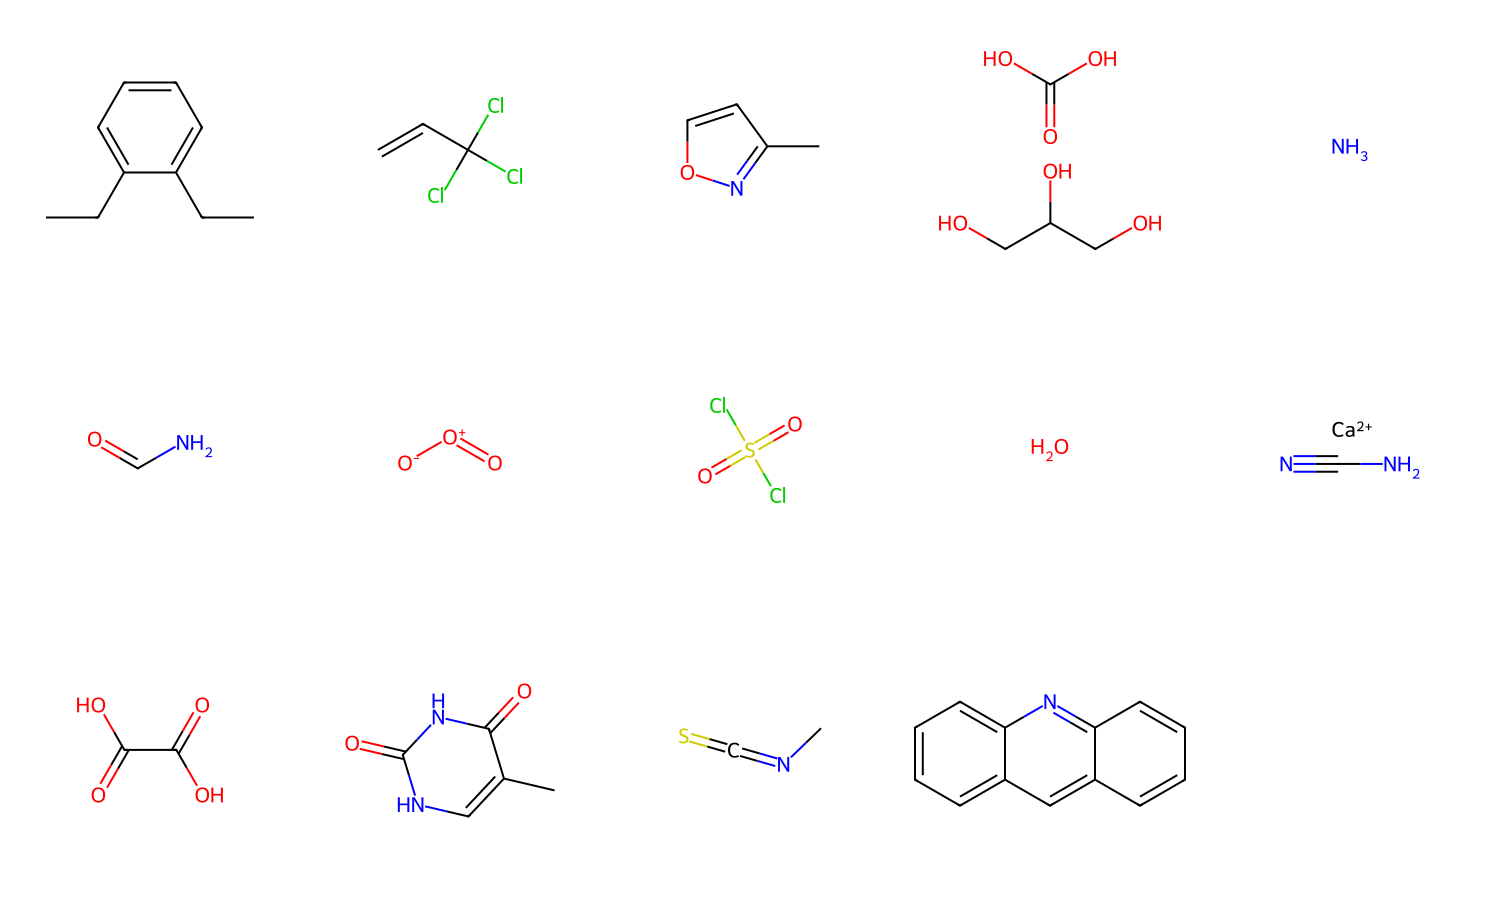

In [15]:
# draw n=3 outlier structure
outliners = [Chem.MolFromSmiles(x) for x in fps_xgboost_outliers['SMILES']]
Draw.MolsToGridImage(outliners, subImgSize=(300,300), molsPerRow=5, maxMols=50)

In [16]:
# n is 2 or 3. Points 2 or 3 sdr away from the prediction line are likely to be outliers
n = 2
fps_xgboost_outliers2 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
len(fps_xgboost_outliers2)

64

In [17]:
fps_xgboost_outliers2


,Mol_No,SMILES,actual,predict,residual,std_residual
3,44,CCc1ccccc1CC,0.1,10.421125,10.321125,3.377670
24,163,COc1c(Cl)cccc1Cl,8.4,2.029392,-6.370608,-2.084832
26,170,Nc1ccccn1,8.1,17.052330,8.952330,2.929721
39,243,ClC(Cl)(Cl)C=C,15.5,3.726994,-11.773006,-3.852810
44,274,Cc1ccon1,14.8,5.107706,-9.692294,-3.171880
...,...,...,...,...,...,...
130,817,CC(=C)C(O)=O,2.8,9.112592,6.312592,2.065846
135,842,CC\C(C)=N\O,4.9,11.013959,6.113959,2.000842
141,873,C[S](=O)(=O)C=C,19.6,12.194545,-7.405455,-2.423494
156,964,ClC(=O)C(Cl)=O,3.8,10.565939,6.765939,2.214207


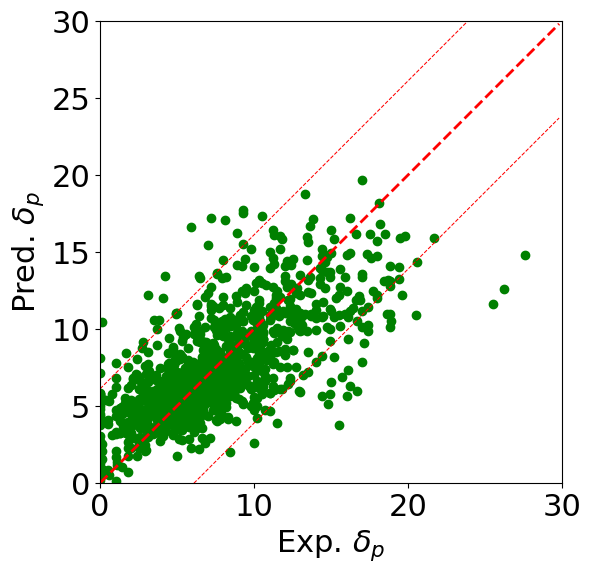

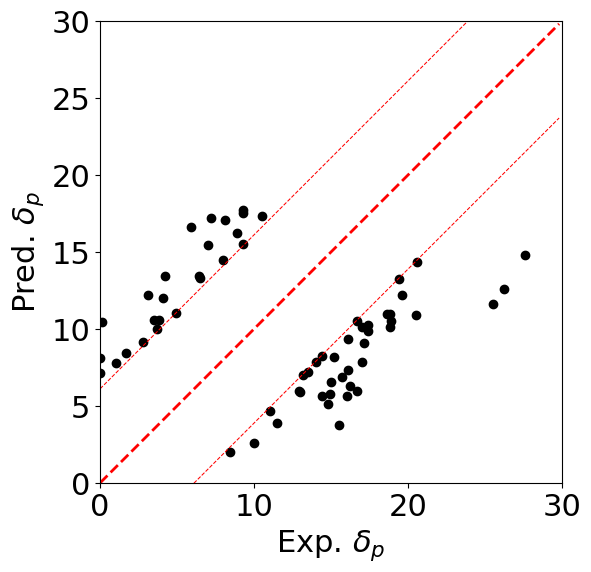

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Set font size
plt.rc('font', size=22)

# --- recalculate for Hansen p ---
fps_xgboost['residual'] = fps_xgboost['predict'] - fps_xgboost['actual']

sdr_p = np.sqrt((fps_xgboost['residual']**2).sum() / (len(fps_xgboost) - 2))

fps_xgboost['std_residual'] = fps_xgboost['residual'] / sdr_p

# residual threshold
n = 2
fps_xgboost_outliers = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]

# -------- Plot 1: all molecules --------
plt.figure(figsize=(6,6))

ln = np.arange(0, 30, 0.2)

# ideal agreement and residual boundaries
plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr_p, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr_p, 'r--', linewidth=0.75)

# scatter plot
plt.scatter(
    x=fps_xgboost['actual'],
    y=fps_xgboost['predict'],
    color='green'
)

plt.xlabel(r'Exp. $\delta_p$')
plt.ylabel(r'Pred. $\delta_p$')

plt.xlim([0,30])
plt.ylim([0,30])

plt.gca().set_aspect('equal', adjustable='box')

# save figure
plt.savefig("xgboost_hansen_p2_all_points.png", dpi=300, bbox_inches="tight")
plt.show()


# -------- Plot 2: outliers only --------
plt.figure(figsize=(6,6))

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr_p, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr_p, 'r--', linewidth=0.75)

plt.scatter(
    x=fps_xgboost_outliers['actual'],
    y=fps_xgboost_outliers['predict'],
    color='black'
)

plt.xlabel(r'Exp. $\delta_p$')
plt.ylabel(r'Pred. $\delta_p$')

plt.xlim([0,30])
plt.ylim([0,30])

plt.gca().set_aspect('equal', adjustable='box')

# save figure
plt.savefig("xgboost_hansen_p2_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences wil

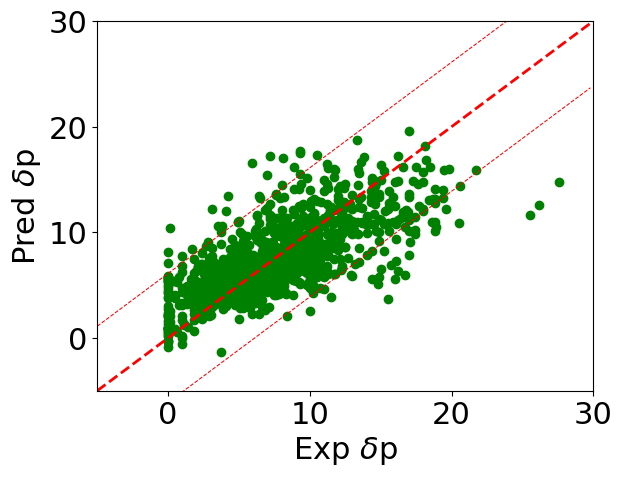

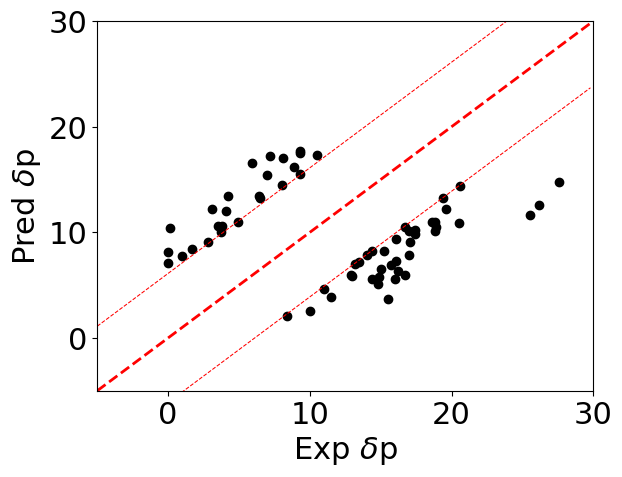

In [19]:
# plot two figures
plt.figure(2)

# plot of exp vs pred of all molecules in the dataset
# The thick red lines indicate ideal agreement between the predicted and experimental values. 
# The dashed red lines indicate 2 srd (n=2) away from the ideal agreement. 
ln = np.arange(-5, 30, 0.2)
plt.plot(ln, ln,'r--', linewidth = '2')
plt.plot(ln, ln+n*sdr,'r--', linewidth = '0.75')
plt.plot(ln, ln-n*sdr,'r--', linewidth = '0.75')
plt.scatter(x=fps_xgboost['actual'], y=fps_xgboost['predict'], color='green')
plt.xlabel('Exp $\delta$p')
plt.ylabel('Pred $\delta$p')
plt.xlim([-5,30])
plt.ylim([-5,30])
plt.show()

# Plot of the outliers identified 
# check visually to confirm they are on or beyond 2 srd
ln = np.arange(-5, 30, 0.2)
plt.plot(ln, ln,'r--', linewidth = '2')
plt.plot(ln, ln+n*sdr,'r--', linewidth = '0.75')
plt.plot(ln, ln-n*sdr,'r--', linewidth = '0.75')
plt.scatter(x=fps_xgboost_outliers2['actual'], y=fps_xgboost_outliers2['predict'], color='black')
plt.xlabel('Exp $\delta$p')
plt.ylabel('Pred $\delta$p')
plt.xlim([-5,30])
plt.ylim([-5,30])
plt.show()

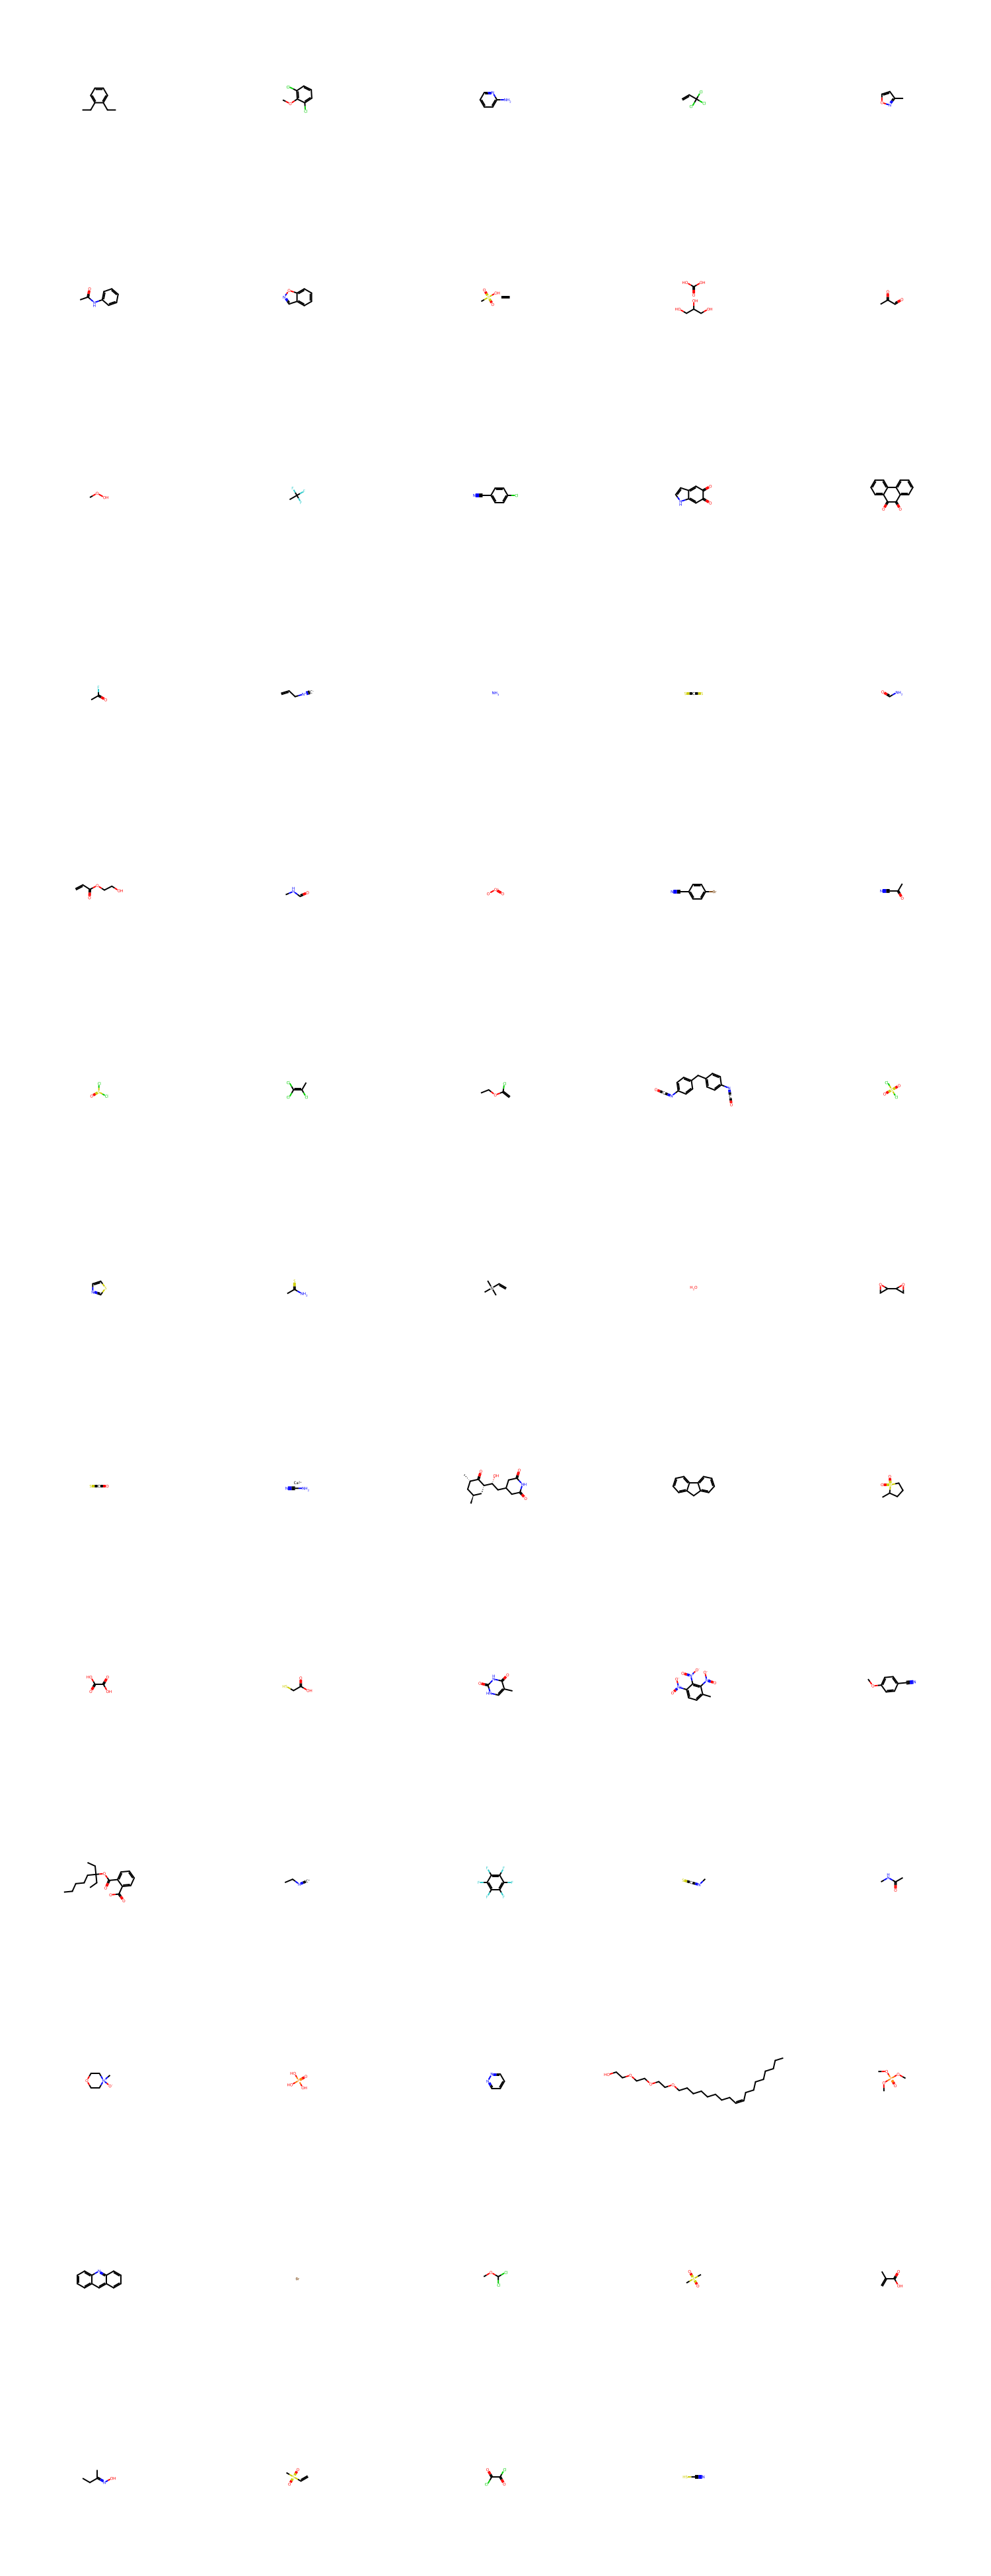

In [20]:
# draw n=2 outlier structure
outliners2 = [Chem.MolFromSmiles(x) for x in fps_xgboost_outliers2['SMILES']]
Draw.MolsToGridImage(outliners2, subImgSize=(300,300), molsPerRow=5, maxMols=100)

In [21]:
# save outliers (n=2) info to a csv file
fps_xgboost_outliers2.to_csv('fps_xgboost_p_outliers2.csv')

In [22]:
from rdkit.Chem import Descriptors
gpHSP_data = pd.read_csv('/Users/favour/Desktop/untitled folder/dataset/hansen_1k_smiles_shorter.csv')
mol_smiles = gpHSP_data['SMILES']

# calculate molecular weight of the full dataset
molwt = [(Descriptors.ExactMolWt(Chem.MolFromSmiles(x))) for x in gpHSP_data['SMILES']]
np_molwt = np.asarray(molwt)

# calculate molecular weight of outliers
molwt_outliers2 = [(Descriptors.ExactMolWt(Chem.MolFromSmiles(x))) for x in fps_xgboost_outliers2['SMILES']]
np_molwt_outliers2 = np.asarray(molwt_outliers2)

# Compare average molecular weight for full data and outliers
print(np.average(np_molwt))
print(np.average(np_molwt_outliers2))

131.2953603288794
118.21164805522156


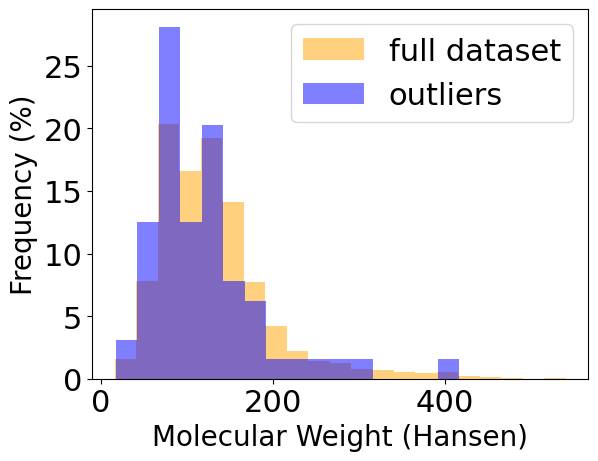

In [23]:
# plot molecular weight distribution for the full dataset and the outliers
bin_width = 25
df = pd.DataFrame(np_molwt, columns = ["full dataset"])
df2 = pd.DataFrame(np_molwt_outliers2, columns = ["outliers"])

ax = df.plot.hist(bins=(np.arange(min(molwt), max(molwt)+bin_width, bin_width)), alpha=0.5, color='orange', weights=np.ones_like(df.index) *100/ len(df))
df2.plot(kind='hist', bins=(np.arange(min(molwt_outliers2), max(molwt_outliers2)+bin_width, bin_width)), alpha=0.5, color='blue', weights=np.ones_like(df2.index) *100 /len(df2), ax=ax)
ax.set_xlabel("Molecular Weight (Hansen)", size=20)
ax.set_ylabel("Frequency (%)", size=20)
plt.show()

In [24]:
# n = 2 outliers
n = 2
fps_xgboost_outliers_n2 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
num_outliers_n2 = len(fps_xgboost_outliers_n2)

print("Number of outliers at n = 2:", num_outliers_n2)

# n = 3 outliers
n = 3
fps_xgboost_outliers_n3 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
num_outliers_n3 = len(fps_xgboost_outliers_n3)

print("Number of outliers at n = 3:", num_outliers_n3)

Number of outliers at n = 2: 64
Number of outliers at n = 3: 14
